# NODOSPLAZA

**Objetivos:**
1. Mapa de calor: temperatura y personas    
2. Monitoreo de mascotas y personas     
3. Monitoreo de uso y estado del mobiliario 
Modelo principal: **YOLOv8s**   
Identifica personas, gatos, perros, sillas y bancas.    

Modelos complementarios:    
**BDRAR**: para generar máscara de sombra, preentrenado, sin finetuning.       
**OpenCV:** detección de cambio en mobiliario con bboxes manuales       
**pythermalcomfort:**  cálculo de UTCI      
**KMeans:** mapa de islas de calor percibido            

Hay **métricas** que se miden por snapshot (1 foto+data sensor de ese momento), y otras que se miden por batch (después de procesar varios snapshots):

Por snapshot:           
**Crowd density** (n° personas actual)      
**Conteo mascotas** actual      
**Shade utilization** (%actual de personas en sombra)       
**Uso mobiliario** (sí/no para cada uno)        
**UTCI** (cálculo con datos de los sensores)        

Por batch:      
**ocupación sostenida** (tiempo estadía calculado desde el n° personas antes vs n° personas ahora)     
**Activity classification** (reposo/circulación para mascotas y personas, se compara bbox entre snapshots)      
**Uso mobiliario** (demanda baja/media/alta, contar interacciones)      
**Shade utilization histórico** (promedio x hora x zona)        
**Correlaciones** (UV vs sombra, UTCI vs dwell; x día o por semana)     
**KMeans** (mapa de islas de calor)         


Pipeline tareas de este nb:
- fase 0.5: insertar imagenes de cámara
- fase 1: yolo detectar personas perros y mobiliario y contar la densidad de personas y mascotas
- fase 2: bdrar (sombra) y cruzar con bboxes personas
- fase 3: conteo uso mobiliario
- fase 3.5: ordenar data obtenida e insertar datos sensores
- fase 4: pythermalcomfort para calcular utci
- fase 5: amononar datos (inferencias de las detecciones)
- fase 5.5: guardarlos en bd
- fase 6: cada x cantidad de imágenes, consultar la bd y extraer datos para obetner las métricas por batch, y gardar en bd
- fase 7: kmeans mapa de islas de calor


In [1]:
# %pip install ultralytics opencv-python numpy matplotlib pythermalcomfort scikit-learn torch torchvision scipy requests pillow pandas seaborn

#### FASE 0.5: insertar imágenes de cámara

In [2]:
# [CAMBIAR A FUTURO]: ajustar cuando esté instalada la cam
# (!!!): revisar
# [AJUSTABLE]: modificar para mejorar el funcionamiento

In [3]:
#imports
import sys
import os
import subprocess
import random
import json
import datetime
import csv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist
from PIL import Image
from io import BytesIO
import requests
import torch
import torch.nn as nn
from torchvision import transforms
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pythermalcomfort.models import utci
from ultralytics import YOLO
import warnings
import glob
warnings.filterwarnings('ignore')

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\thop\profile.py:12: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(torch.__version__) < LooseVersion("1.0.0"):
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\thop\profile.py:12: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(torch.__version__) < LooseVersion("1.0.0"):
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\thop\profile.py:68: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(torch.__version__) >= LooseVersion("1.1.0"):
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundatio

In [4]:
#setup
# Imagen: debe coincidir con lo que manda la RPi (!!!)
ANCHO = 1280
ALTO  = 720

# YOLO
CLASES_INTERES = {
    0:  'persona',
    13: 'banca',
    15: 'gato',
    16: 'perro',
    56: 'silla',
    # (!!!) agregar clases custom después del fine-tuning con datos del canil: rampa, túnel, piscina, bebedero, dispensador de bolsas
}
UMBRAL_CONFIANZA = 0.20 # [AJUSTABLE] umbral de confianza YOLO

# Colores visualización (BGR)
COLOR_PERSONA            = (0, 255, 0)    # verde
COLOR_MASCOTA            = (0, 165, 255)  # naranja
COLOR_MOBILIARIO_LIBRE   = (255, 200, 0)  # azul claro
COLOR_MOBILIARIO_OCUPADO = (0, 0, 255)    # rojo

# Parque 
AREA_PARQUE_M2 = 3000 # [CAMBIAR A FUTURO] valor inventado por el momento, verificar cuando esté instalada la cam

In [5]:
#definiciones funciones de carga de imgs
def cargar_imagen_local(ruta):
    """Carga una imagen desde disco y la redimensiona."""
    img = cv2.imread(ruta)
    if img is None:
        raise FileNotFoundError(f'No se encontró imagen en: {ruta}')
    return cv2.resize(img, (ANCHO, ALTO))


def mostrar_imagen(img_bgr, titulo='Imagen'):
    """Muestra una imagen BGR en el notebook."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 8))
    plt.imshow(img_rgb)
    plt.title(titulo, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
#selección de fuente y carga
# [AJUSTABLE] opciones: 'frames_schuylkill/', 'frames_cinquez/' 
#schuylkill es un video de unos 20 min de un parqucito con hartas personas y perros.
#cinquez es parte de un livestream que capturé por 12h de un parque mucho más amplio y mucho menos afluencia
CARPETA_FRAMES = 'frames_cinquez_20260530/'
frames_disponibles = sorted(glob.glob(f'{CARPETA_FRAMES}*.jpg'))

# [CAMBIAR A FUTURO] en producción img_original viene del HTTP POST de la RPi
img_original = cargar_imagen_local(random.choice(frames_disponibles))

#### FASE 1: YOLO

In [7]:
#cargar modelo
modelo_yolo = YOLO('yolov8s.pt')

In [8]:
#funciones correr modelo
def correr_yolo(img_bgr, modelo, umbral=UMBRAL_CONFIANZA):
    result = modelo(
        img_bgr,
        conf         = umbral,
        iou          = 0.5,   # [AJUSTABLE] bajar si hay detecciones duplicadas
        imgsz        = 1280,  # [AJUSTABLE] bajar a 640 si el servidor es lento
        agnostic_nms = True,
        verbose      = False
    )[0]

    personas, mascotas, mobiliario = [], [], []
    for caja in result.boxes:
        clase_id = int(caja.cls)
        if clase_id not in CLASES_INTERES:
            continue
        x1, y1, x2, y2 = map(int, caja.xyxy[0].tolist())
        det = {
            'clase':     CLASES_INTERES[clase_id],
            'confianza': round(float(caja.conf), 3),
            'bbox':      (x1, y1, x2, y2),
            'centro':    ((x1+x2)//2, (y1+y2)//2),
        }
        if clase_id == 0:           personas.append(det)
        elif clase_id in [15, 16]:  mascotas.append(det)
        elif clase_id in [13, 56]:  mobiliario.append(det)

    return {'personas': personas, 'mascotas': mascotas, 'mobiliario': mobiliario}


def generar_canvas(detecciones, categorias, alto, ancho):
    """Canvas gaussiano de densidad — se reutiliza en Fase 5."""
    canvas = np.zeros((alto, ancho), dtype=np.float32)
    for cat in categorias:
        for det in detecciones[cat]:
            cx, cy = det['centro']
            if 0 <= cx < ancho and 0 <= cy < alto:
                canvas[cy, cx] += 1.0
    canvas = gaussian_filter(canvas, sigma=40)  # [AJUSTABLE] suavizado
    if canvas.max() > 0:
        canvas /= canvas.max()
    return canvas

In [9]:
#correr modelo
detecciones = correr_yolo(img_original, modelo_yolo)
alto, ancho    = img_original.shape[:2]
canvas_heatmap = generar_canvas(detecciones, ['personas', 'mascotas'], alto, ancho)

#### FASE 2: BDRAR

In [10]:
# setup BDRAR : clonar repo y descargar pesos
# ATENCIÓN: pesos BDRAR (3000.pth) requieren descarga manual:
#   1. https://github.com/zijundeng/BDRAR ->  README -> "pretrained model" -> Google Drive
#   2. Descargar 3000.pth
#   3. Copiar a: Shadow-Detection-and-Removal/ckpt/BDRAR/3000.pth

# clonar repo
if not os.path.exists('./Shadow-Detection-and-Removal'):
    subprocess.run(['git', 'clone',
                    'https://github.com/RolandGao/Shadow-Detection-and-Removal'],
                   check=True)

RUTA_BDRAR = os.path.abspath('./Shadow-Detection-and-Removal')

# descargar backbone ResNeXt101
ruta_resnext = os.path.join(RUTA_BDRAR, 'resnext', 'resnext_101_32x4d.pth')
if not os.path.exists(ruta_resnext):
    import gdown
    gdown.download(
        'https://drive.google.com/uc?id=1dnH-IHwmu9xFPlyndqI6MfF4LvH6JKNQ',
        ruta_resnext, quiet=False
    )

# parchar config.py con ruta absoluta del backbone
# necesario porque el repo tiene el path hardcodeado como ruta relativa
ruta_config = os.path.join(RUTA_BDRAR, 'resnext', 'config.py')
with open(ruta_config, 'w') as f:
    f.write(f"resnext_101_32_path = r'{ruta_resnext}'\n")
print(f'✅ config.py parcheado: {ruta_resnext}')

# verificar pesos BDRAR
ruta_bdrar_pesos = os.path.join(RUTA_BDRAR, 'ckpt', 'BDRAR', '3000.pth')
os.makedirs(os.path.dirname(ruta_bdrar_pesos), exist_ok=True)
if not os.path.exists(ruta_bdrar_pesos):
    print('⚠️  Pesos BDRAR no encontrados — descarga manual requerida')
    print(f'   → Copiar 3000.pth a: {ruta_bdrar_pesos}')

✅ config.py parcheado: c:\Users\ACER\Desktop\u\nodosplaza\Shadow-Detection-and-Removal\resnext\resnext_101_32x4d.pth


In [11]:
#cargar modelo BDRAR
import importlib.util

spec = importlib.util.spec_from_file_location('model', os.path.join(RUTA_BDRAR, 'model.py'))
modulo_model = importlib.util.module_from_spec(spec)
if RUTA_BDRAR not in sys.path:
    sys.path.insert(0, RUTA_BDRAR)
spec.loader.exec_module(modulo_model)

modelo_bdrar = modulo_model.BDRAR()
modelo_bdrar.load_state_dict(
    torch.load(ruta_bdrar_pesos, map_location='cpu')
)
_=modelo_bdrar.eval()

In [12]:
#ejecutar BDRAR
transformacion_bdrar = transforms.Compose([
    transforms.Resize((416, 416)),  # [AJUSTABLE] bajar a 256 si es lento
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def detectar_sombra(img_bgr, modelo, sat):
    alto, ancho = img_bgr.shape[:2]
    x = transformacion_bdrar(Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))).unsqueeze(0)
    with torch.no_grad():
        pred = modelo(x).squeeze().cpu().numpy()
    pred = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)
    pred = cv2.resize(pred, (ancho, alto))
    umbral = float(np.clip(0.00 + (sat / 4000), 0.00, 0.60))  # [AJUSTABLE]
    return (pred > umbral).astype(np.uint8)

def persona_en_sombra(bbox, mascara):
    x1, y1, x2, y2 = bbox
    region = mascara[y1:y2, x1:x2]
    if region.size == 0: return False, 0.0
    pct = float(np.mean(region))
    return pct > 0.20, round(pct, 3)  # [AJUSTABLE] umbral sombra por detección

def es_de_noche(img_bgr, umbral_brillo=110):  # [AJUSTABLE]
    return float(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)[:,:,2].mean()) < umbral_brillo

def es_nublado(img_bgr, umbral_sat=75):  # [AJUSTABLE]
    return float(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)[:,:,1].mean()) < umbral_sat

hsv_orig    = cv2.cvtColor(img_original, cv2.COLOR_BGR2HSV)
sat_orig    = round(float(hsv_orig[:,:,1].mean()), 2)
brillo_orig = round(float(hsv_orig[:,:,2].mean()), 2)
noche       = es_de_noche(img_original)
nublado     = es_nublado(img_original)
shade_utilization_pct = None

if noche or nublado:
    mascara_sombra = np.zeros((ALTO, ANCHO), dtype=np.uint8)
else:
    mascara_sombra = detectar_sombra(img_original, modelo_bdrar, sat_orig)
    for d in detecciones['personas'] + detecciones['mascotas']:
        d['en_sombra'], d['pct_sombra'] = persona_en_sombra(d['bbox'], mascara_sombra)
    todos = detecciones['personas'] + detecciones['mascotas']
    n_s   = sum(1 for d in todos if d['en_sombra'])
    shade_utilization_pct = round(n_s / len(todos), 3) if todos else 0.0

#### FASE 3: uso mobiliario


In [13]:
#bboxes mobiliario
# [CAMBIAR A FUTURO] coordenadas se definen el día de instalación de la cámara
# coordenadas (x1, y1, x2, y2) en píxeles sobre imagen 1280×720
MOBILIARIO_BBOXES = {
    'banca_1': (1038, 370, 1141, 426),
    'banca_2': (896, 360, 991, 413),
    'banca_3': (839, 293, 865, 319),
    'banca_4': (1100, 350, 1141, 380),
    'banca_5': (920, 330, 970, 370),
    'techo':   (870, 400, 1170, 270), 
}

In [14]:
#inferir uso mobiliario snapshot
def inferir_uso_snapshot(detecciones, mobiliario_bboxes):
    """
    Cuenta personas y mascotas cuya bbox intersecta con cada mueble.
    Retorna {nombre: {ocupado, n_usuarios, n_personas, n_mascotas}}
    """
    def area_interseccion(a, b):
        return max(0, min(a[2],b[2]) - max(a[0],b[0])) * \
               max(0, min(a[3],b[3]) - max(a[1],b[1]))

    resultado = {}
    for nombre, bbox_m in mobiliario_bboxes.items():
        area_m     = (bbox_m[2]-bbox_m[0]) * (bbox_m[3]-bbox_m[1])
        n_personas = sum(1 for p in detecciones['personas']
                         if area_m > 0 and area_interseccion(p['bbox'], bbox_m) / area_m > 0.2)  # [AJUSTABLE]
        n_mascotas = sum(1 for m in detecciones['mascotas']
                         if area_m > 0 and area_interseccion(m['bbox'], bbox_m) / area_m > 0.2)  # [AJUSTABLE]
        n_usuarios = n_personas + n_mascotas
        resultado[nombre] = {
            'ocupado':    n_usuarios > 0,
            'n_usuarios': n_usuarios,
            'n_personas': n_personas,
            'n_mascotas': n_mascotas,
        }
    return resultado

In [15]:
#ejecutar uso mobiliario
uso_mobiliario_snapshot = inferir_uso_snapshot(detecciones, MOBILIARIO_BBOXES)

#### fase 3.5: ordenar data + sensores

In [16]:
#datos sensores
# [CAMBIAR A FUTURO] en producción vienen del HTTP POST del Nodo B junto con la imagen
# sensores: AHT10 (tdb, rh), anemómetro (v), GYML8511 (uv), TEMT6000 (lux)
sensor_data = {
    'timestamp': datetime.datetime.now().isoformat(),
    'tdb': 28.5,   # [INVENTADO] temperatura aire °C   — AHT10
    'rh':  55.0,   # [INVENTADO] humedad relativa %    — AHT10
    'v':   1.2,    # [INVENTADO] velocidad viento m/s  — anemómetro
    'uv':  7.2,    # [INVENTADO] índice UV             — GYML8511
    'lux': 38600,  # [INVENTADO] luz ambiental lx      — TEMT6000
}

In [17]:
#construir snapshot
def construir_snapshot_record(detecciones, mascara_sombra, shade_utilization_pct,
                               uso_mobiliario_snapshot, sensor_data):
    """
    Consolida todos los datos del snapshot en un dict plano.
    Combina outputs de YOLO, BDRAR, uso mobiliario y sensores.
    """
    lux  = sensor_data['lux']
    hora = datetime.datetime.fromisoformat(sensor_data['timestamp']).hour

    # [AJUSTABLE] umbrales de clasificación de luz
    if lux >= 10000:   condicion_luz = 'diurno'
    elif lux >= 1000:  condicion_luz = 'nublado'
    else:              condicion_luz = 'baja_luz'

    hora_operacional = 8 <= hora < 20  # [AJUSTABLE] horario de operación

    return {
        'timestamp':        sensor_data['timestamp'],
        'tdb':              sensor_data['tdb'],
        'rh':               sensor_data['rh'],
        'v':                sensor_data['v'],
        'uv':               sensor_data['uv'],
        'lux':              lux,
        'condicion_luz':    condicion_luz,
        'hora_operacional': hora_operacional,
        'shade_confiable':  condicion_luz == 'diurno',
        'snapshot_valido': True,
        'n_personas':            len(detecciones['personas']),
        'n_mascotas':            len(detecciones['mascotas']),
        'centros_personas':      [p['centro'] for p in detecciones['personas']],
        'centros_mascotas':      [m['centro'] for m in detecciones['mascotas']],
        'shade_utilization_pct': shade_utilization_pct,
        'shade_parque_pct':      round(float(np.mean(mascara_sombra)), 3),
        'uso_mobiliario':        uso_mobiliario_snapshot,
    }


snapshot_record = construir_snapshot_record(
    detecciones, mascara_sombra, shade_utilization_pct,
    uso_mobiliario_snapshot, sensor_data
)

#### FASE 4: PYTHERMALCOMFORT

In [18]:
#funciones UTCI
def calcular_tr(tdb, uv, shade_parque_pct):
    """
    Estima temperatura radiante media (tr) desde UV y sombra del parque.
    Factor 1.8 es empírico — [AJUSTABLE] calibrar con datos reales del Canil.
    """
    if shade_parque_pct > 0.6:      # [AJUSTABLE] umbral sombra alta
        tr = tdb + 2
    elif shade_parque_pct < 0.3:    # [AJUSTABLE] umbral sombra baja
        tr = tdb + uv * 1.8         # [AJUSTABLE] factor radiante UV
    else:
        factor = (0.6 - shade_parque_pct) / (0.6 - 0.3)
        tr = (tdb + 2) + factor * ((tdb + uv * 1.8) - (tdb + 2))
    return round(tr, 2)


def calcular_y_clasificar_utci(sensor_data, shade_parque_pct):
    """
    Calcula UTCI y lo clasifica en la escala estándar.
    Retorna dict con utci_valor, utci_categoria y tr_estimada.
    """
    tdb = sensor_data['tdb']
    tr  = calcular_tr(tdb, sensor_data['uv'], shade_parque_pct)

    utci_valor = round(float(utci(tdb=tdb, tr=tr,
                                   v=sensor_data['v'],
                                   rh=sensor_data['rh']).utci), 2)

    if utci_valor < 9:     categoria = 'sin estres (frío)'
    elif utci_valor < 26:  categoria = 'confortable'
    elif utci_valor < 32:  categoria = 'estres moderado'
    elif utci_valor < 38:  categoria = 'estres fuerte'
    else:                  categoria = 'estres muy fuerte'

    return {'utci_valor': utci_valor, 'utci_categoria': categoria, 'tr_estimada': tr}

In [19]:
#ejecutar UTCI
resultado_utci = calcular_y_clasificar_utci(
    sensor_data, snapshot_record['shade_parque_pct']
)
snapshot_record['utci_valor']     = resultado_utci['utci_valor']
snapshot_record['utci_categoria'] = resultado_utci['utci_categoria']
snapshot_record['tr_estimada']    = resultado_utci['tr_estimada']

#### FASE 5: amononar datos

In [20]:
#calcular aglomeración
def calcular_aglomeracion(n_personas, area_m2=AREA_PARQUE_M2):
    """
    Calcula densidad de personas y detecta aglomeración.
    Umbral 0.35 p/m² basado en estándares de confort en espacios públicos — [INVENTADO] verificar.
    """
    densidad = round(n_personas / area_m2, 4)
    return {
        'densidad':     densidad,
        'aglomeracion': densidad > 0.35,  # [AJUSTABLE]
    }

In [21]:
#ejecutar aglomeración
resultado_aglomeracion          = calcular_aglomeracion(snapshot_record['n_personas'])
snapshot_record['densidad']     = resultado_aglomeracion['densidad']
snapshot_record['aglomeracion'] = resultado_aglomeracion['aglomeracion']

#### fase 5.5: guardar data en bd

In [22]:
#setup BD
# [CAMBIAR A FUTURO] reemplazar por PostgreSQL/RDS cuando el servidor esté levantado

RUTA_CSV = 'snapshots.csv'  # [CAMBIAR A FUTURO] apuntar a RDS

HEADERS = [
    'timestamp', 'tdb', 'rh', 'v', 'uv', 'lux',
    'condicion_luz', 'hora_operacional', 'shade_confiable', 'snapshot_valido',
    'n_personas', 'n_mascotas',
    'centros_personas', 'centros_mascotas',
    'shade_utilization_pct', 'shade_parque_pct',
    'uso_mobiliario',
    'utci_valor', 'utci_categoria', 'tr_estimada',
    'densidad', 'aglomeracion',
]

def init_csv(ruta, headers):
    """Crea el CSV con headers si no existe. Si ya existe solo hace append."""
    if not os.path.exists(ruta):
        with open(ruta, 'w', newline='', encoding='utf-8') as f:
            csv.DictWriter(f, fieldnames=headers).writeheader()

def guardar_snapshot(snapshot_record, ruta, headers):
    """Agrega una fila al CSV. Serializa listas y dicts como JSON string."""
    fila = {
        campo: json.dumps(snapshot_record.get(campo), ensure_ascii=False)
               if isinstance(snapshot_record.get(campo), (list, dict))
               else snapshot_record.get(campo)
        for campo in headers
    }
    with open(ruta, 'a', newline='', encoding='utf-8') as f:
        csv.DictWriter(f, fieldnames=headers).writerow(fila)

In [23]:
#ejecutar guardar snapshot
init_csv(RUTA_CSV, HEADERS)
guardar_snapshot(snapshot_record, RUTA_CSV, HEADERS)

#### FASE 6: procesar data batch


In [24]:
#procesar frames batch
CARPETA_BATCH = 'frames_cinquez_20260530/'
N_FRAMES      = 4000  # [AJUSTABLE]

frames_batch = sorted(glob.glob(f'{CARPETA_BATCH}*.jpg'))[:N_FRAMES]
init_csv(RUTA_CSV, HEADERS)

for i, ruta_frame in enumerate(frames_batch):
    nombre = os.path.basename(ruta_frame).replace('.jpg', '')
    try:
        ts = datetime.datetime.strptime(nombre, '%Y%m%d_%H%M%S').isoformat()
    except ValueError:
        ts = datetime.datetime.now().isoformat()

    img      = cargar_imagen_local(ruta_frame)
    det      = correr_yolo(img, modelo_yolo)
    hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    sat      = round(float(hsv[:,:,1].mean()), 2)
    noche_f  = es_de_noche(img)
    nublado_f= es_nublado(img)

    if noche_f or nublado_f:
        masc     = np.zeros((ALTO, ANCHO), dtype=np.uint8)
        shade_ut = 0.0
    else:
        masc = detectar_sombra(img, modelo_bdrar, sat)
        for d in det['personas'] + det['mascotas']:
            d['en_sombra'], d['pct_sombra'] = persona_en_sombra(d['bbox'], masc)
        todos    = det['personas'] + det['mascotas']
        shade_ut = round(sum(1 for d in todos if d['en_sombra']) / len(todos), 3) if todos else 0.0

    uso_mob = inferir_uso_snapshot(det, MOBILIARIO_BBOXES)
    sd = {
        'timestamp': ts,
        'tdb': round(random.uniform(18.0, 36.0), 1),  # [INVENTADO]
        'rh':  round(random.uniform(25.0, 80.0), 1),  # [INVENTADO]
        'v':   round(random.uniform(0.0,  5.0),  1),  # [INVENTADO]
        'uv':  round(random.uniform(0.0, 11.0),  1),  # [INVENTADO]
        'lux': random.randint(500, 80000),             # [INVENTADO]
    }
    snap = construir_snapshot_record(det, masc, shade_ut, uso_mob, sd)
    res_utci = calcular_y_clasificar_utci(sd, snap['shade_parque_pct'])
    snap['utci_valor']     = res_utci['utci_valor']
    snap['utci_categoria'] = res_utci['utci_categoria']
    snap['tr_estimada']    = res_utci['tr_estimada']
    res_agl = calcular_aglomeracion(snap['n_personas'])
    snap['densidad']     = res_agl['densidad']
    snap['aglomeracion'] = res_agl['aglomeracion']
    guardar_snapshot(snap, RUTA_CSV, HEADERS)

In [25]:
#cargar histórico
def cargar_historico(ruta, n_ultimos=None, horas=None):
    """
    Carga snapshots desde CSV, deserializa JSON, filtra válidos.
    En producción: reemplazar por query a PostgreSQL.
    """
    df = pd.read_csv(ruta)
    for col in ['centros_personas', 'centros_mascotas', 'uso_mobiliario']:
        df[col] = df[col].apply(lambda x: json.loads(x) if pd.notna(x) else [])
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    df = df.sort_values('timestamp').reset_index(drop=True)
    if horas is not None:
        corte = df['timestamp'].max() - pd.Timedelta(hours=horas)
        df    = df[df['timestamp'] >= corte].reset_index(drop=True)
    if n_ultimos is not None:
        df = df.tail(n_ultimos).reset_index(drop=True)
    return df

df_historico = cargar_historico(RUTA_CSV)

In [26]:
#ocupación sostenida
INTERVALO_MIN = 5  # [AJUSTABLE]

def calcular_ocupacion_sostenida(df, intervalo_min=INTERVALO_MIN):
    """
    Estima ocupación sostenida contando ventanas consecutivas con personas.
    Más honesto que dwell time porque no trackea individuos.
    """
    con_personas = df['n_personas'] > 0
    max_consec = consec = 0
    for tiene in con_personas:
        consec = consec + 1 if tiene else 0
        max_consec = max(max_consec, consec)
    return {
        'n_snapshots_con_personas': int(con_personas.sum()),
        'n_snapshots_total':        len(df),
        'max_consecutivos':         max_consec,
        'ocupacion_sostenida_min':  max_consec * intervalo_min,
    }

ocupacion = calcular_ocupacion_sostenida(df_historico)

In [27]:
#activity classification
UMBRAL_MOVIMIENTO_PX = 50  # [AJUSTABLE]

def calcular_activity_classification(df):
    """
    Compara centros entre snapshots consecutivos.
    Movimiento > umbral → circulando, estable → reposo.
    """
    estados_p, estados_m = [], []
    for i in range(1, len(df)):
        for centros_ant, centros_act, estados in [
            (df.loc[i-1,'centros_personas'], df.loc[i,'centros_personas'], estados_p),
            (df.loc[i-1,'centros_mascotas'], df.loc[i,'centros_mascotas'], estados_m),
        ]:
            if centros_ant and centros_act:
                for d in cdist(centros_ant, centros_act).min(axis=1):
                    estados.append('circulando' if d > UMBRAL_MOVIMIENTO_PX else 'reposo')

    def distribucion(estados):
        if not estados: return {'circulando': 0.0, 'reposo': 0.0}
        total = len(estados)
        return {e: round(estados.count(e)/total, 3) for e in set(estados)}

    return {'personas': distribucion(estados_p), 'mascotas': distribucion(estados_m)}

activity = calcular_activity_classification(df_historico)

In [28]:
#uso mobiliario batch
def calcular_uso_mobiliario_batch(df, mobiliario_bboxes):
    """Tasa de uso y demanda por mueble sobre el histórico."""
    n_total   = len(df)
    resultado = {}
    for nombre in mobiliario_bboxes:
        n_ocupado = sum(
            1 for uso in df['uso_mobiliario']
            if isinstance(uso, dict) and nombre in uso
            and uso[nombre].get('ocupado', False)
        )
        tasa_uso = round(n_ocupado / n_total, 3) if n_total > 0 else 0.0
        resultado[nombre] = {
            'tasa_uso': tasa_uso,
            'demanda':  'sin uso' if tasa_uso == 0
                        else 'alta demanda' if tasa_uso >= 0.3  # [AJUSTABLE]
                        else 'uso normal',
        }
    return resultado

uso_batch = calcular_uso_mobiliario_batch(df_historico, MOBILIARIO_BBOXES)

In [29]:
#shade histórico
def calcular_shade_historico(df):
    """Promedio de shade_utilization_pct por hora del día."""
    df_h = df.copy()
    df_h['hora'] = df_h['timestamp'].dt.hour
    return df_h.groupby('hora')['shade_utilization_pct'].mean().reset_index()

shade_historico = calcular_shade_historico(df_historico)

In [30]:
#correlaciones
def calcular_correlaciones(df):
    """
    Correlación de Pearson entre pares de métricas.
    Requiere ≥ 7 días de datos para ser estadísticamente significativo.
    """
    pares = [
        ('uv',        'shade_utilization_pct', 'UV vs Shade utilization'),
        ('utci_valor','n_personas',             'UTCI vs N personas'),
        ('v',         'n_personas',             'Viento vs N personas'),
        ('lux',       'shade_utilization_pct',  'Lux vs Shade utilization'),
    ]
    return {
        etiqueta: {
            'r':     round(df[col_a].corr(df[col_b]), 3),
            'nivel': 'alta' if abs(df[col_a].corr(df[col_b])) > 0.7
                     else 'media' if abs(df[col_a].corr(df[col_b])) > 0.4
                     else 'baja'
        }
        for col_a, col_b, etiqueta in pares
    }

correlaciones = calcular_correlaciones(df_historico)

In [31]:
#guardar batch
RUTA_CSV_BATCH = 'batch.csv'  # [CAMBIAR A FUTURO] tabla batch en PostgreSQL
HEADERS_BATCH  = [
    'timestamp_batch', 'n_snapshots_procesados', 'ocupacion_sostenida_min',
    'n_snapshots_con_personas', 'activity_personas', 'activity_mascotas',
    'uso_mobiliario_batch', 'correlaciones',
]

batch_record = {
    'timestamp_batch':          datetime.datetime.now().isoformat(),
    'n_snapshots_procesados':   len(df_historico),
    'ocupacion_sostenida_min':  ocupacion['ocupacion_sostenida_min'],
    'n_snapshots_con_personas': ocupacion['n_snapshots_con_personas'],
    'activity_personas':        activity['personas'],
    'activity_mascotas':        activity['mascotas'],
    'uso_mobiliario_batch':     uso_batch,
    'correlaciones':            correlaciones,
}

init_csv(RUTA_CSV_BATCH, HEADERS_BATCH)
fila_batch = {
    campo: json.dumps(valor, ensure_ascii=False)
           if isinstance(valor, (dict, list)) else valor
    for campo, valor in batch_record.items()
}
with open(RUTA_CSV_BATCH, 'a', newline='', encoding='utf-8') as f:
    csv.DictWriter(f, fieldnames=HEADERS_BATCH).writerow(fila_batch)

#### FASE 7: kmeans

In [32]:
#preparar features zonas
def preparar_features_zonas(df_historico, mobiliario_bboxes):
    """
    Calcula promedios históricos por zona semántica.
    Zonas = bboxes manuales del mobiliario + zona general del parque.
    """
    zonas = [{
        'zona':            'parque_general',
        'utci_prom':       round(df_historico['utci_valor'].mean(), 2),
        'shade_pct_prom':  round(df_historico['shade_parque_pct'].mean(), 3),
        'n_personas_prom': round(df_historico['n_personas'].mean(), 2),
        'ocupacion_prom':  round((df_historico['n_personas'] > 0).mean(), 3),
    }]
    for nombre in mobiliario_bboxes:
        ocupados   = df_historico['uso_mobiliario'].apply(
            lambda uso: uso.get(nombre, {}).get('ocupado', False)
            if isinstance(uso, dict) else False
        )
        n_usuarios = df_historico['uso_mobiliario'].apply(
            lambda uso: uso.get(nombre, {}).get('n_usuarios', 0)
            if isinstance(uso, dict) else 0
        )
        zonas.append({
            'zona':            nombre,
            'utci_prom':       round(df_historico['utci_valor'].mean(), 2),
            'shade_pct_prom':  round(df_historico['shade_parque_pct'].mean(), 3),
            'n_personas_prom': round(n_usuarios.mean(), 2),
            'ocupacion_prom':  round(ocupados.mean(), 3),
        })
    return pd.DataFrame(zonas)

df_zonas = preparar_features_zonas(df_historico, MOBILIARIO_BBOXES)

In [33]:
#codo kmeans
def calcular_codo(df_zonas):
    """Determina el número óptimo de clusters. Con pocas zonas suele ser 2 o 3."""
    features  = ['utci_prom', 'shade_pct_prom', 'n_personas_prom', 'ocupacion_prom']
    X         = df_zonas[features].values
    escalador = StandardScaler()
    X_scaled  = escalador.fit_transform(X)
    n_max     = min(len(df_zonas), 6)
    # inercias calculadas pero no graficadas en v2_small
    _ = [KMeans(n_clusters=n, random_state=42, n_init=10).fit(X_scaled).inertia_
         for n in range(2, n_max+1)]
    return X_scaled, escalador

X_scaled, escalador = calcular_codo(df_zonas)

In [34]:
#correr kmeans
N_CLUSTERS = 2  # [AJUSTABLE] según método del codo

# [INVENTADO] etiquetas semánticas — calibrar con criterio experto
ETIQUETAS_CONFORT = {
    0: 'confortable',
    1: 'estres leve',
    2: 'estres moderado',
    3: 'alto estres',
}

def correr_kmeans(df_zonas, X_scaled, n_clusters=N_CLUSTERS):
    """
    Corre KMeans y asigna etiquetas ordenadas por utci_prom ascendente.
    Cluster 0 = más fresco, último = más caliente.
    """
    km        = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df_result = df_zonas.copy()
    df_result['cluster_raw'] = km.fit_predict(X_scaled)
    mapa_clusters = {
        viejo: nuevo for nuevo, viejo in enumerate(
            df_result.groupby('cluster_raw')['utci_prom'].mean().sort_values().index
        )
    }
    df_result['cluster']  = df_result['cluster_raw'].map(mapa_clusters)
    df_result['etiqueta'] = df_result['cluster'].map(ETIQUETAS_CONFORT)
    return df_result, km

df_kmeans, modelo_kmeans = correr_kmeans(df_zonas, X_scaled, N_CLUSTERS)

In [35]:
#guardar kmeans
RUTA_CSV_KMEANS = 'kmeans.csv'  # [CAMBIAR A FUTURO] tabla kmeans en PostgreSQL
HEADERS_KMEANS  = ['timestamp_kmeans', 'n_clusters', 'n_snapshots_usados', 'zonas']

kmeans_record = {
    'timestamp_kmeans':   datetime.datetime.now().isoformat(),
    'n_clusters':         N_CLUSTERS,
    'n_snapshots_usados': len(df_historico),
    'zonas': df_kmeans[['zona','utci_prom','shade_pct_prom',
                         'n_personas_prom','cluster','etiqueta']].to_dict(orient='records'),
}

init_csv(RUTA_CSV_KMEANS, HEADERS_KMEANS)
fila_kmeans = {
    campo: json.dumps(valor, ensure_ascii=False)
           if isinstance(valor, (dict, list)) else valor
    for campo, valor in kmeans_record.items()
}
with open(RUTA_CSV_KMEANS, 'a', newline='', encoding='utf-8') as f:
    csv.DictWriter(f, fieldnames=HEADERS_KMEANS).writerow(fila_kmeans)

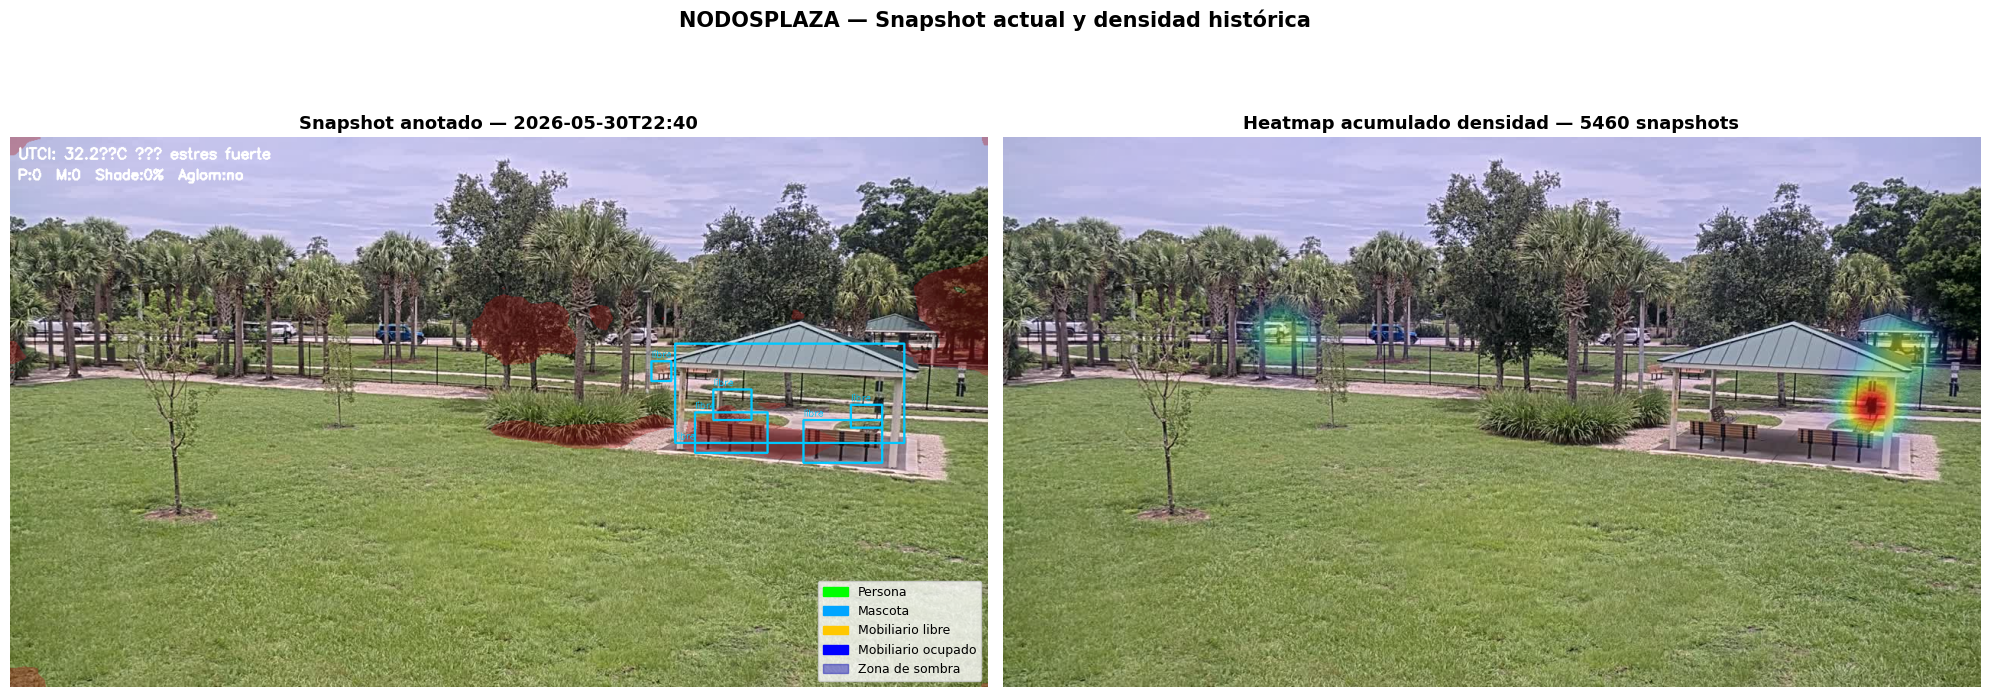

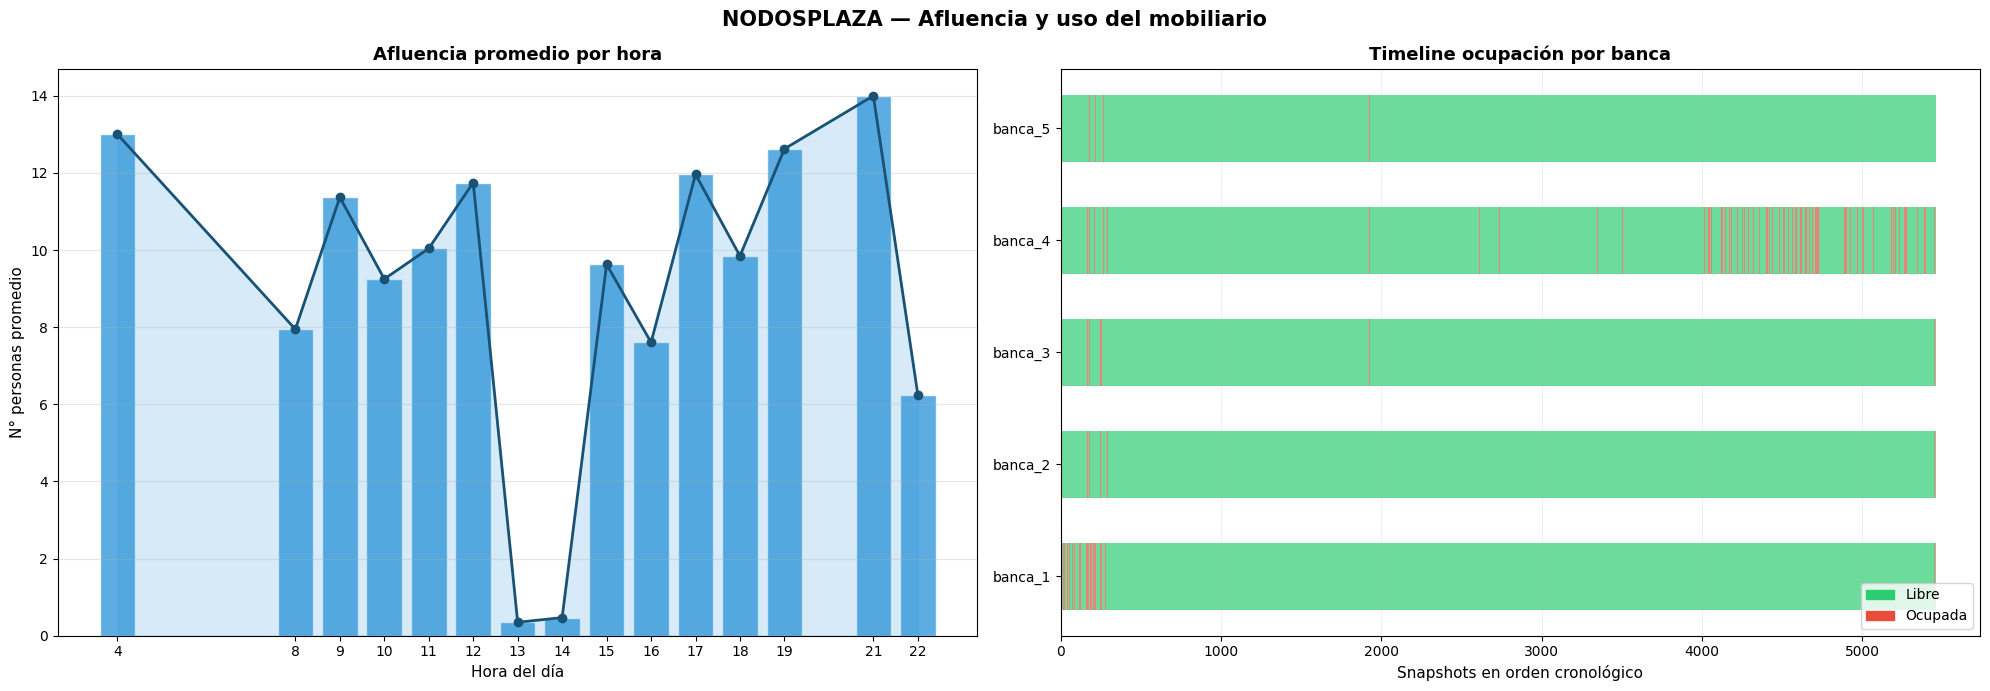

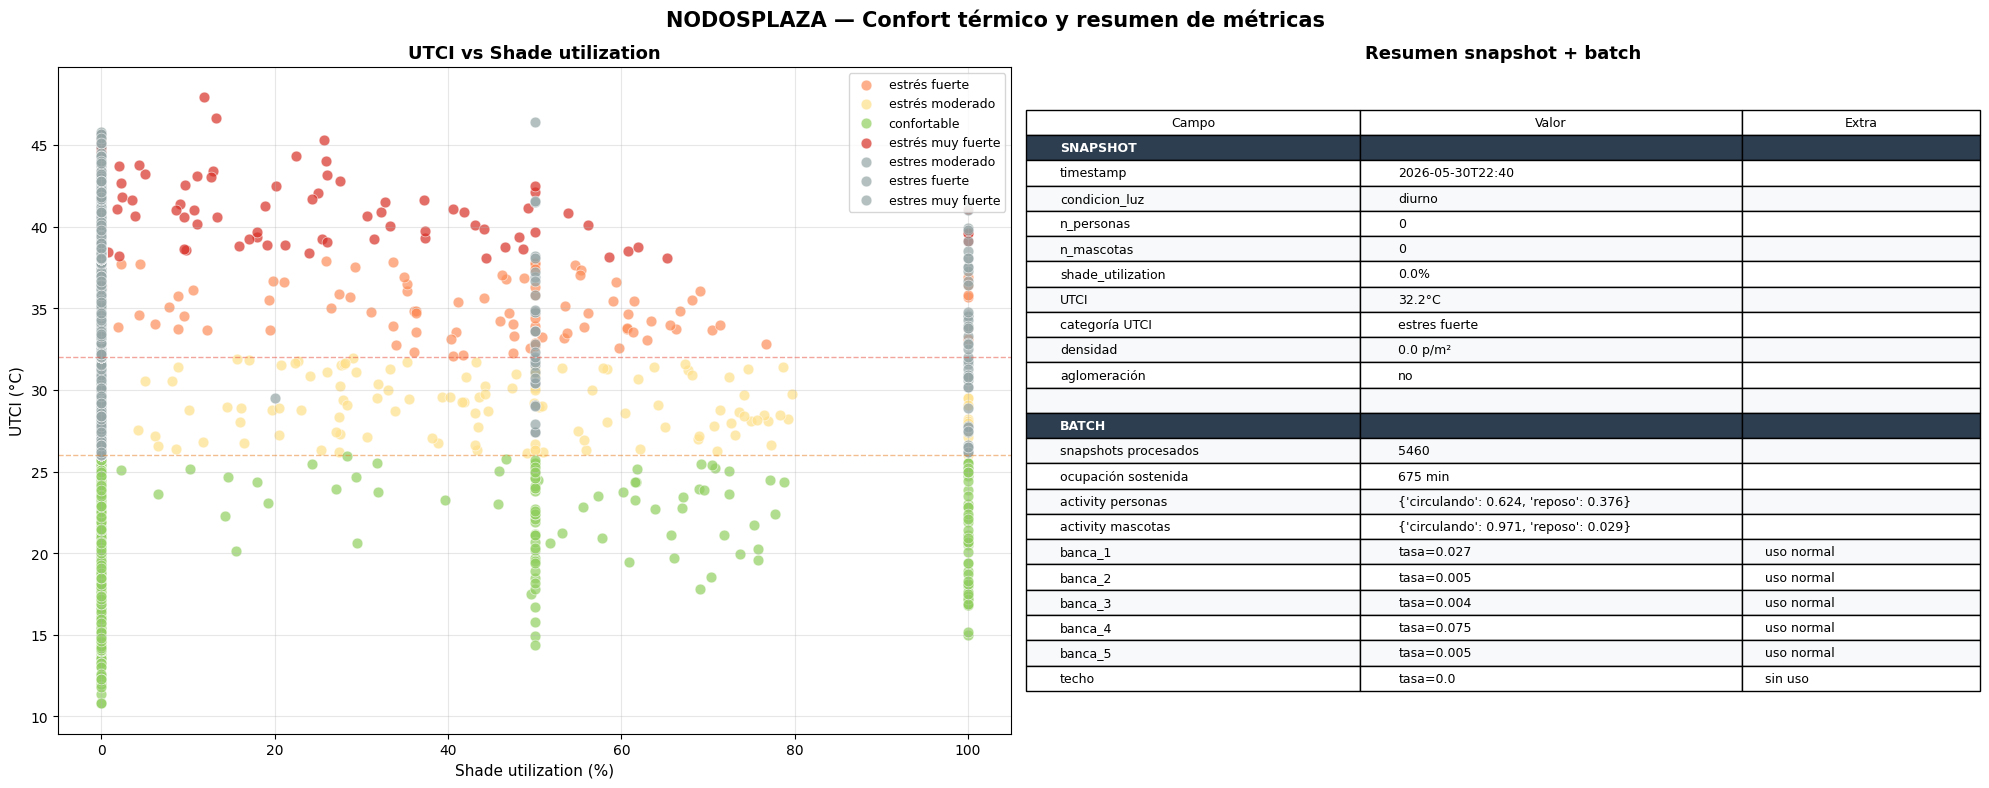

In [36]:
#visualización final presentación

# ── helpers ───────────────────────────────────────────────────────────────────
shade_pct = (snapshot_record['shade_utilization_pct'] or 0)

COLORES_CONFORT = {
    'confortable':     '#2ecc71',
    'estrés leve':     '#f1c40f',
    'estrés moderado': '#e67e22',
    'alto estrés':     '#e74c3c',
}
COLORES_UTCI = {
    'sin estrés (frío)': '#4575b4',
    'confortable':        '#91cf60',
    'estrés moderado':    '#fee08b',
    'estrés fuerte':      '#fc8d59',
    'estrés muy fuerte':  '#d73027',
}

# ── FIG 1: imagen anotada | heatmap acumulado ─────────────────────────────────
fig1, ax1 = plt.subplots(1, 2, figsize=(20, 8))

# panel izquierdo — snapshot anotado
img_anotada = img_original.copy()
mascara_3d  = mascara_sombra[:,:,np.newaxis].astype(np.float32)
img_f       = img_anotada.astype(np.float32)
img_f       = img_f * (1 - mascara_3d*0.35) + np.array([30,30,180], np.float32) * (mascara_3d*0.35)
img_anotada = np.clip(img_f, 0, 255).astype(np.uint8)

for p in detecciones['personas']:
    x1,y1,x2,y2 = p['bbox']
    cv2.rectangle(img_anotada, (x1,y1), (x2,y2), COLOR_PERSONA, 2)
for m in detecciones['mascotas']:
    x1,y1,x2,y2 = m['bbox']
    cv2.rectangle(img_anotada, (x1,y1), (x2,y2), COLOR_MASCOTA, 2)
for nombre, (x1,y1,x2,y2) in MOBILIARIO_BBOXES.items():
    estado = snapshot_record['uso_mobiliario'][nombre]
    color  = COLOR_MOBILIARIO_OCUPADO if estado['ocupado'] else COLOR_MOBILIARIO_LIBRE
    cv2.rectangle(img_anotada, (x1,y1), (x2,y2), color, 2)
    cv2.putText(img_anotada, f"{'ocup' if estado['ocupado'] else 'libre'}",
                (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

cv2.putText(img_anotada,
            f"UTCI: {snapshot_record['utci_valor']}°C — {snapshot_record['utci_categoria']}",
            (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2)
cv2.putText(img_anotada,
            f"P:{snapshot_record['n_personas']}  M:{snapshot_record['n_mascotas']}  "
            f"Shade:{shade_pct*100:.0f}%  Aglom:{'sí' if snapshot_record['aglomeracion'] else 'no'}",
            (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

ax1[0].imshow(cv2.cvtColor(img_anotada, cv2.COLOR_BGR2RGB))
ax1[0].set_title(f'Snapshot anotado — {snapshot_record["timestamp"][:16]}', fontsize=13, fontweight='bold')
ax1[0].axis('off')

# leyenda panel izquierdo
leyenda_snap = [
    patches.Patch(color='#00ff00', label='Persona'),
    patches.Patch(color='#00a5ff', label='Mascota'),
    patches.Patch(color='#ffc800', label='Mobiliario libre'),
    patches.Patch(color='#0000ff', label='Mobiliario ocupado'),
    patches.Patch(color='#1e1eb4', alpha=0.5, label='Zona de sombra'),
]
ax1[0].legend(handles=leyenda_snap, loc='lower right', fontsize=9, framealpha=0.8)

# panel derecho — heatmap acumulado de densidad (todos los frames del histórico)
canvas_acum = np.zeros((ALTO, ANCHO), dtype=np.float32)
for centros in df_historico['centros_personas']:
    if isinstance(centros, list):
        for cx, cy in centros:
            if 0 <= cx < ANCHO and 0 <= cy < ALTO:
                canvas_acum[cy, cx] += 1.0
canvas_acum = gaussian_filter(canvas_acum, sigma=30)  # [AJUSTABLE]
if canvas_acum.max() > 0:
    canvas_acum /= canvas_acum.max()

img_rgb_base = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
calor_mask   = canvas_acum[:,:,np.newaxis]
img_acum     = np.clip(
    img_rgb_base * (1 - calor_mask*0.7) +
    plt.cm.jet(canvas_acum)[:,:,:3] * (calor_mask*0.7),
    0, 1
)
ax1[1].imshow(img_acum)
ax1[1].set_title(f'Heatmap acumulado densidad — {len(df_historico)} snapshots', fontsize=13, fontweight='bold')
ax1[1].axis('off')

plt.suptitle('NODOSPLAZA — Snapshot actual y densidad histórica', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# ── FIG 2: n_personas por hora | timeline ocupación bancas ───────────────────
fig2, ax2 = plt.subplots(1, 2, figsize=(20, 7))

# panel izquierdo — promedio n_personas por hora
df_h = df_historico.copy()
df_h['hora'] = df_h['timestamp'].dt.hour
personas_x_hora = df_h.groupby('hora')['n_personas'].mean()

ax2[0].bar(personas_x_hora.index, personas_x_hora.values,
           color='#3498db', alpha=0.8, edgecolor='white')
ax2[0].plot(personas_x_hora.index, personas_x_hora.values,
            marker='o', color='#1a5276', linewidth=2)
ax2[0].fill_between(personas_x_hora.index, personas_x_hora.values,
                    alpha=0.2, color='#3498db')
ax2[0].set_xlabel('Hora del día', fontsize=11)
ax2[0].set_ylabel('N° personas promedio', fontsize=11)
ax2[0].set_title('Afluencia promedio por hora', fontsize=13, fontweight='bold')
ax2[0].set_xticks(sorted(df_h['hora'].unique()))
ax2[0].grid(axis='y', alpha=0.3)

# panel derecho — timeline ocupación por banca
bancas    = [n for n in MOBILIARIO_BBOXES if n != 'techo']
n_bancas  = len(bancas)
colores_t = ['#2ecc71', '#e74c3c']  # verde=libre, rojo=ocupado

for idx, nombre in enumerate(bancas):
    ocupacion_t = df_historico['uso_mobiliario'].apply(
        lambda uso: 1 if isinstance(uso, dict) and uso.get(nombre, {}).get('ocupado', False) else 0
    )
    timestamps = df_historico['timestamp']
    for i, (ts, ocup) in enumerate(zip(timestamps, ocupacion_t)):
        ax2[1].barh(idx, 1, left=i, color=colores_t[ocup], alpha=0.7, height=0.6)

ax2[1].set_yticks(range(n_bancas))
ax2[1].set_yticklabels(bancas, fontsize=10)
ax2[1].set_xlabel('Snapshots en orden cronológico', fontsize=11)
ax2[1].set_title('Timeline ocupación por banca', fontsize=13, fontweight='bold')
ax2[1].legend(handles=[
    patches.Patch(color='#2ecc71', label='Libre'),
    patches.Patch(color='#e74c3c', label='Ocupada'),
], loc='lower right', fontsize=10)
ax2[1].grid(axis='x', alpha=0.2)

plt.suptitle('NODOSPLAZA — Afluencia y uso del mobiliario', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# ── FIG 3: scatter UTCI vs shade | tabla resumen ─────────────────────────────
fig3, ax3 = plt.subplots(1, 2, figsize=(20, 8))

# panel izquierdo — scatter UTCI vs shade_utilization por categoría
categorias_utci = df_historico['utci_categoria'].unique()
for cat in categorias_utci:
    mask = df_historico['utci_categoria'] == cat
    ax3[0].scatter(
        df_historico.loc[mask, 'shade_utilization_pct'] * 100,
        df_historico.loc[mask, 'utci_valor'],
        color=COLORES_UTCI.get(cat, '#95a5a6'),
        label=cat, alpha=0.7, edgecolors='white', linewidth=0.5, s=60
    )
ax3[0].set_xlabel('Shade utilization (%)', fontsize=11)
ax3[0].set_ylabel('UTCI (°C)', fontsize=11)
ax3[0].set_title('UTCI vs Shade utilization', fontsize=13, fontweight='bold')
ax3[0].legend(fontsize=9, framealpha=0.8)
ax3[0].grid(alpha=0.3)
ax3[0].axhline(y=26, color='#e67e22', linestyle='--', alpha=0.5, linewidth=1)
ax3[0].axhline(y=32, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1)

# panel derecho — tabla resumen snapshot + batch
ax3[1].axis('off')

filas_tabla = [
    ['SNAPSHOT', '', ''],
    ['timestamp',          str(snapshot_record['timestamp'][:16]),          ''],
    ['condicion_luz',      snapshot_record['condicion_luz'],                ''],
    ['n_personas',         str(snapshot_record['n_personas']),              ''],
    ['n_mascotas',         str(snapshot_record['n_mascotas']),              ''],
    ['shade_utilization',  f"{shade_pct*100:.1f}%",                        ''],
    ['UTCI',               f"{snapshot_record['utci_valor']}°C",           ''],
    ['categoría UTCI',     snapshot_record['utci_categoria'],               ''],
    ['densidad',           f"{snapshot_record['densidad']} p/m²",          ''],
    ['aglomeración',       'sí' if snapshot_record['aglomeracion'] else 'no', ''],
    ['', '', ''],
    ['BATCH', '', ''],
    ['snapshots procesados', str(batch_record['n_snapshots_procesados']),   ''],
    ['ocupación sostenida',  f"{batch_record['ocupacion_sostenida_min']} min", ''],
    ['activity personas',    str(batch_record['activity_personas']),        ''],
    ['activity mascotas',    str(batch_record['activity_mascotas']),        ''],
]
for nombre in MOBILIARIO_BBOXES:
    if nombre in uso_batch:
        d = uso_batch[nombre]
        filas_tabla.append([nombre, f"tasa={d['tasa_uso']}", d['demanda']])

cols_tabla  = ['Campo', 'Valor', 'Extra']
tabla = ax3[1].table(
    cellText=filas_tabla,
    colLabels=cols_tabla,
    cellLoc='left',
    loc='center',
    colWidths=[0.35, 0.4, 0.25]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 1.4)

# estilo headers de sección
for i, fila in enumerate(filas_tabla):
    if fila[0] in ['SNAPSHOT', 'BATCH']:
        for j in range(3):
            tabla[i+1, j].set_facecolor('#2c3e50')
            tabla[i+1, j].set_text_props(color='white', fontweight='bold')
    elif i % 2 == 0:
        for j in range(3):
            tabla[i+1, j].set_facecolor('#f8f9fa')

ax3[1].set_title('Resumen snapshot + batch', fontsize=13, fontweight='bold')

plt.suptitle('NODOSPLAZA — Confort térmico y resumen de métricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()